In [3]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Ground Data EDA

In [4]:
measurement_folder = Path('Data/irradiation_measurements')
cbe_measurements = measurement_folder / 'CBE_Data'
mak_measurements = measurement_folder / 'MAK_physics_dept'
ministry_measurements = measurement_folder / 'ministry_energy_ug'

In [5]:
location = 'soroti'
soroti = pd.read_csv(ministry_measurements / f'{location}.csv')
soroti.head()

,datetime,ghi,location,latitude,longitude
0,2020-02-01,2550.0,soroti,1.7153,33.6186
1,2020-02-02,6100.0,soroti,1.7153,33.6186
2,2020-02-03,4690.0,soroti,1.7153,33.6186
3,2020-02-04,6690.0,soroti,1.7153,33.6186
4,2020-02-05,6030.0,soroti,1.7153,33.6186


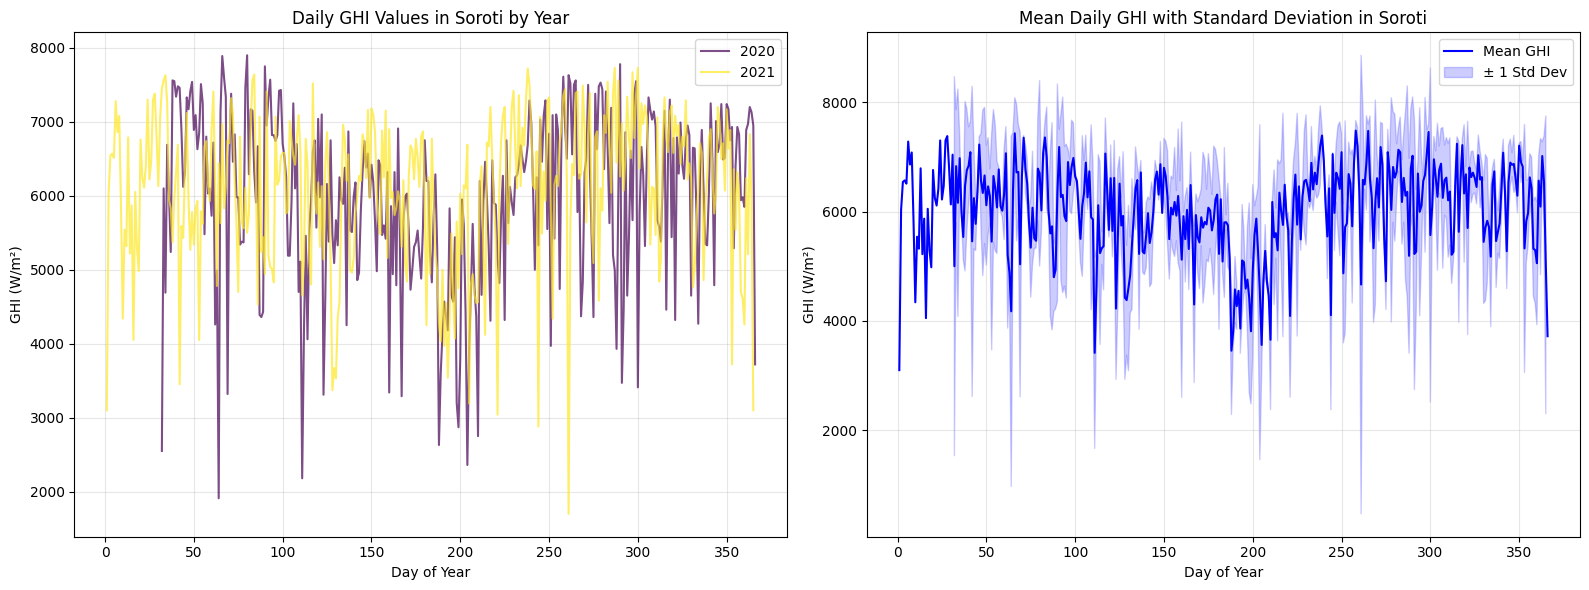

In [6]:
soroti['Date'] = pd.to_datetime(soroti['datetime'])
soroti['Year'] = soroti['Date'].dt.year
soroti['DayOfYear'] = soroti['Date'].dt.dayofyear

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: GHI for all years overlayed
years = soroti['Year'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(years)))

for i, year in enumerate(years):
    year_data = soroti[soroti['Year'] == year]
    axes[0].plot(year_data['DayOfYear'], year_data['ghi'], color=colors[i], alpha=0.7, label=str(year))

axes[0].set_xlabel('Day of Year')
axes[0].set_ylabel('GHI (W/m²)')
axes[0].set_title(f'Daily GHI Values in {location.capitalize()} by Year')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Right plot: Daily mean and std across years
daily_stats = soroti.groupby('DayOfYear')['ghi'].agg(['mean', 'std']).reset_index()

axes[1].plot(daily_stats['DayOfYear'], daily_stats['mean'], color='blue', label='Mean GHI')
axes[1].fill_between(
    daily_stats['DayOfYear'], 
    daily_stats['mean'] - daily_stats['std'], 
    daily_stats['mean'] + daily_stats['std'], 
    color='blue', alpha=0.2, label='± 1 Std Dev'
)

axes[1].set_xlabel('Day of Year')
axes[1].set_ylabel('GHI (W/m²)')
axes[1].set_title(f'Mean Daily GHI with Standard Deviation in {location.capitalize()}')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
def plot_ghi_yearly_distribution(data):
    """
    Create separate figures showing GHI distribution by year and daily statistics for each location.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        DataFrame containing 'datetime' and 'ghi' columns
        
    Returns:
    --------
    fig, axes : tuple
        Figure and axes objects for further customization if needed
    """
    # Prepare date-related columns
    data = data.copy()
    data['Date'] = pd.to_datetime(data['datetime'])
    data['Year'] = data['Date'].dt.year
    data['DayOfYear'] = data['Date'].dt.dayofyear
    
    locations = data['location'].unique()
    all_figs = []
    all_axes = []

    for location in locations:
        location_data = data[data['location'] == location]
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Left plot: GHI for all years overlayed
        years = location_data['Year'].unique()
        color_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
        colors = [color_list[i % len(color_list)] for i in range(len(years))]

        for j, year in enumerate(years):
            year_data = location_data[location_data['Year'] == year]
            axes[0].plot(year_data['DayOfYear'], year_data['ghi'], 
                        color=colors[j], alpha=0.7, label=str(year))

        axes[0].set_xlabel('Day of Year')
        axes[0].set_ylabel('GHI (W/m²)')
        axes[0].set_title(f'Daily GHI Values in {location.capitalize()} by Year')
        axes[0].legend(loc='best')
        axes[0].grid(True, alpha=0.3)

        # Right plot: Daily mean and std across years
        daily_stats = location_data.groupby(['DayOfYear'])['ghi'].agg(['mean', 'std']).reset_index()

        axes[1].plot(daily_stats['DayOfYear'], daily_stats['mean'], 
                    color='blue', label='Mean GHI')
        axes[1].fill_between(
            daily_stats['DayOfYear'], 
            daily_stats['mean'] - daily_stats['std'], 
            daily_stats['mean'] + daily_stats['std'], 
            color='blue', alpha=0.2, label='± 1 Std Dev'
        )

        axes[1].set_xlabel('Day of Year')
        axes[1].set_ylabel('GHI (W/m²)')
        axes[1].set_title(f'Mean Daily GHI with Standard Deviation in {location.capitalize()}')
        axes[1].legend(loc='best')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        all_figs.append(fig)
        all_axes.append(axes)
    
    return all_figs, all_axes

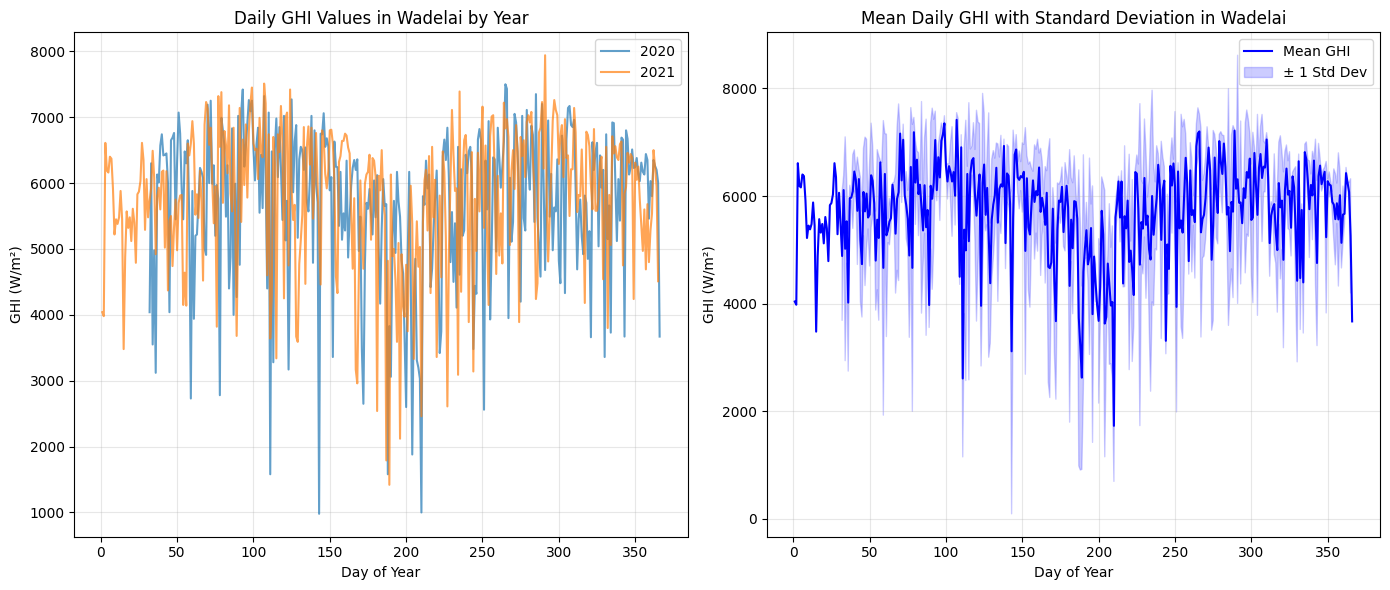

In [8]:
wadelai = pd.read_csv(ministry_measurements / 'wadelai.csv')
fig, axes = plot_ghi_yearly_distribution(wadelai)
plt.show()

In [9]:
list(cbe_measurements.glob('*.csv'))

[PosixPath('Data/irradiation_measurements/CBE_Data/egypt.csv'),
 PosixPath('Data/irradiation_measurements/CBE_Data/ghana.csv'),
 PosixPath('Data/irradiation_measurements/CBE_Data/kenya.csv'),
 PosixPath('Data/irradiation_measurements/CBE_Data/madagascar.csv'),
 PosixPath('Data/irradiation_measurements/CBE_Data/nigeria.csv'),
 PosixPath('Data/irradiation_measurements/CBE_Data/somalia.csv')]

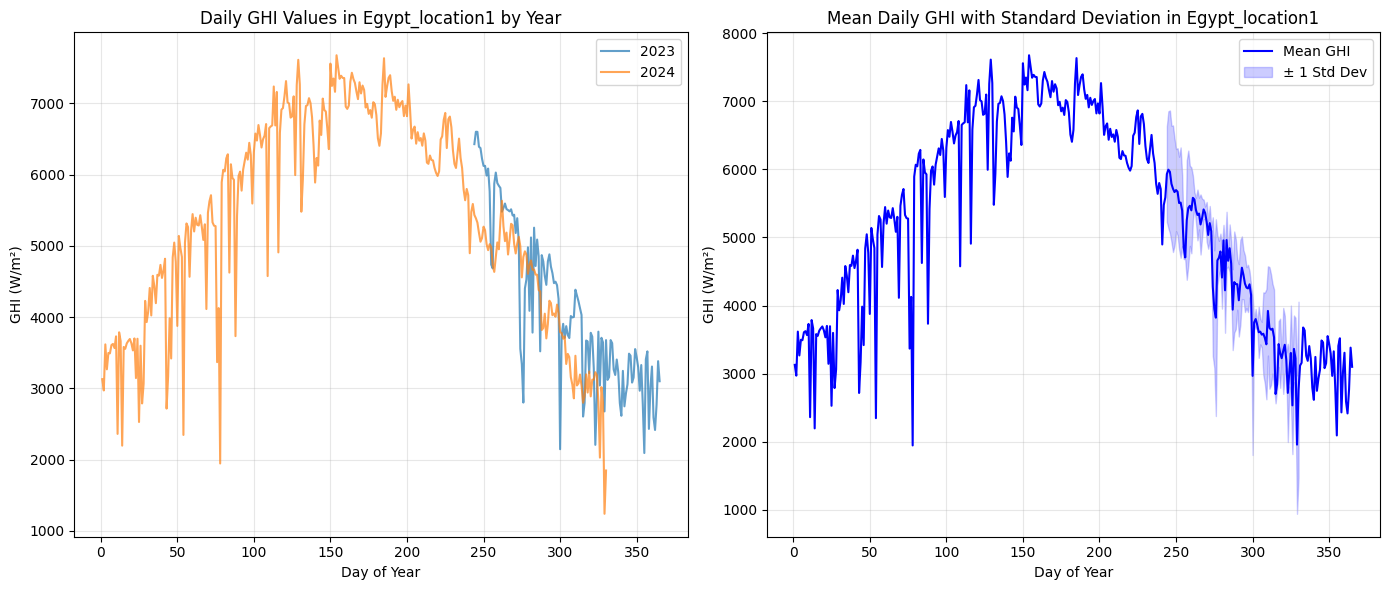

In [10]:
location = 'egypt'
egypt = pd.read_csv(cbe_measurements / f'{location}.csv')
fig, axes = plot_ghi_yearly_distribution(egypt)
plt.show()

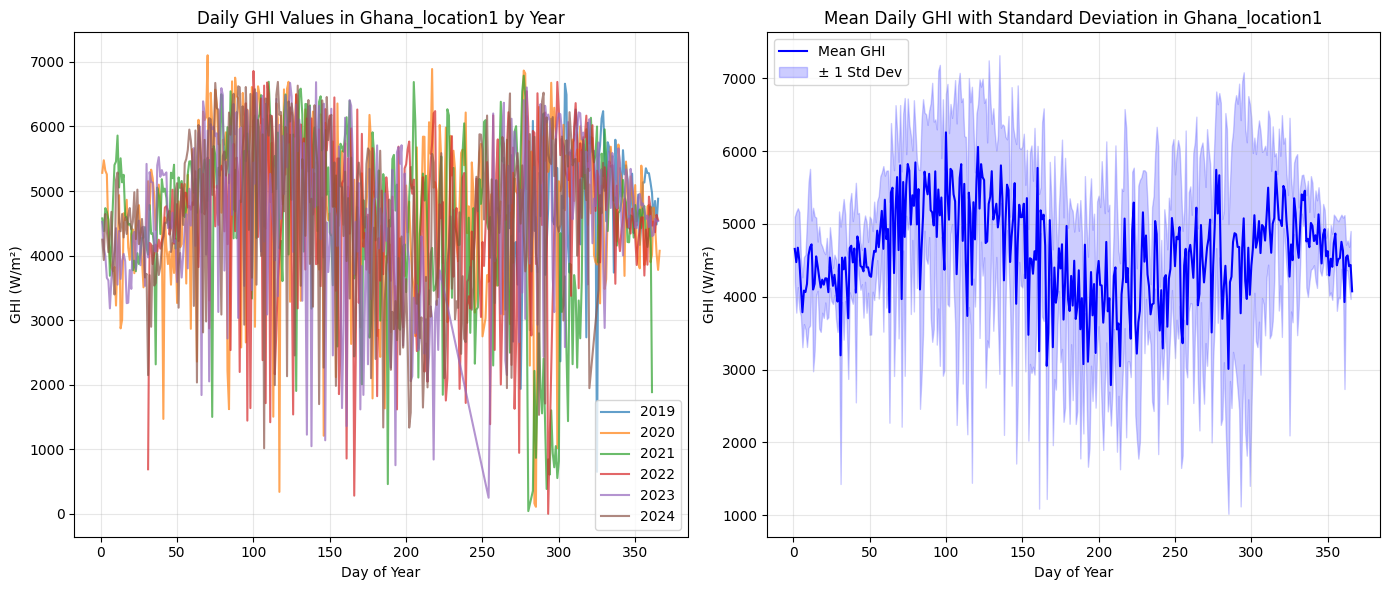

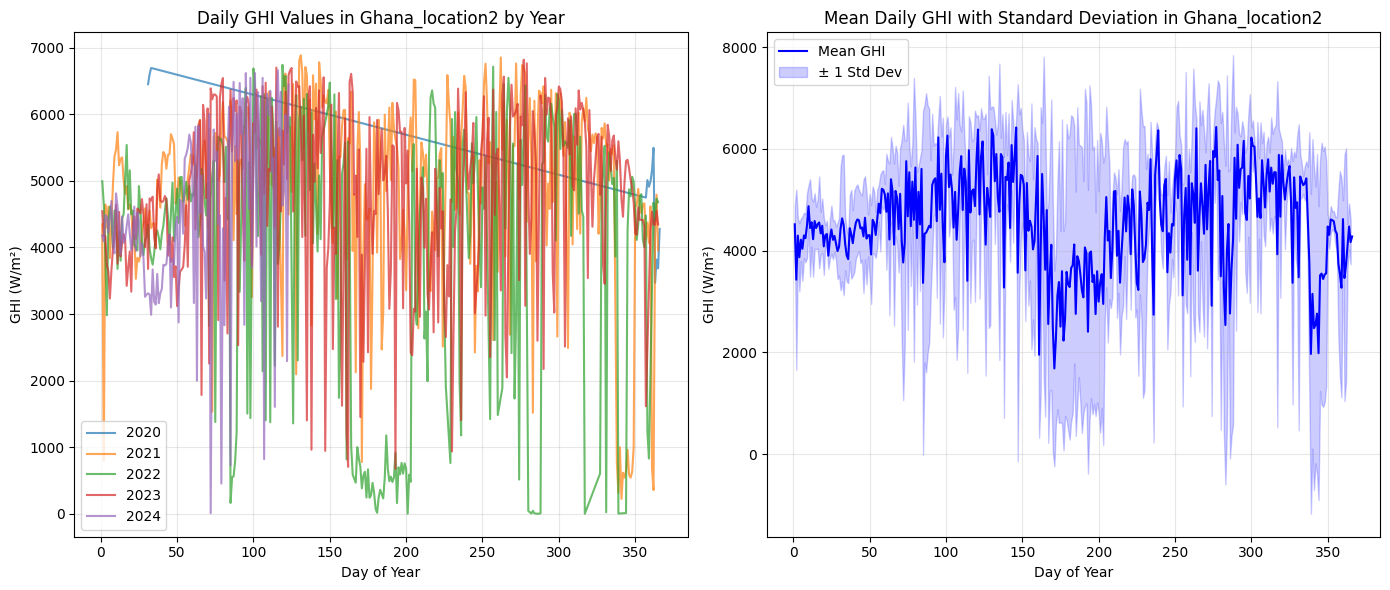

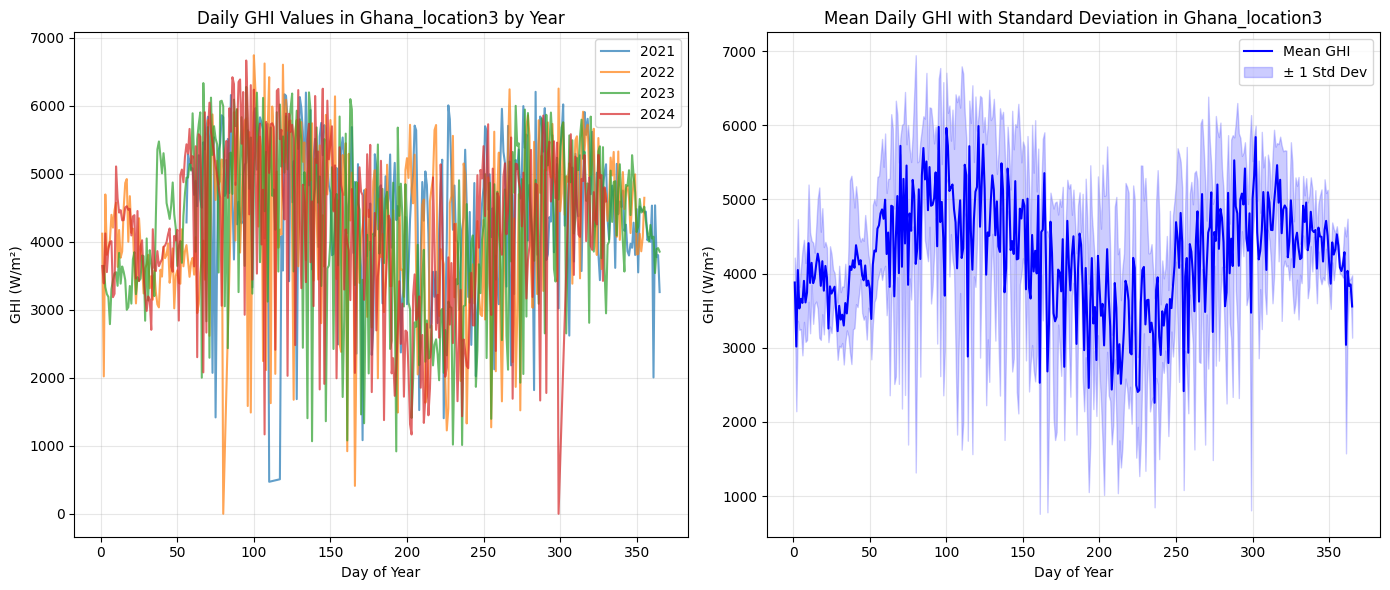

In [11]:
location = 'ghana'
ghana = pd.read_csv(cbe_measurements / f'{location}.csv')
fig, axes = plot_ghi_yearly_distribution(ghana)
plt.show()

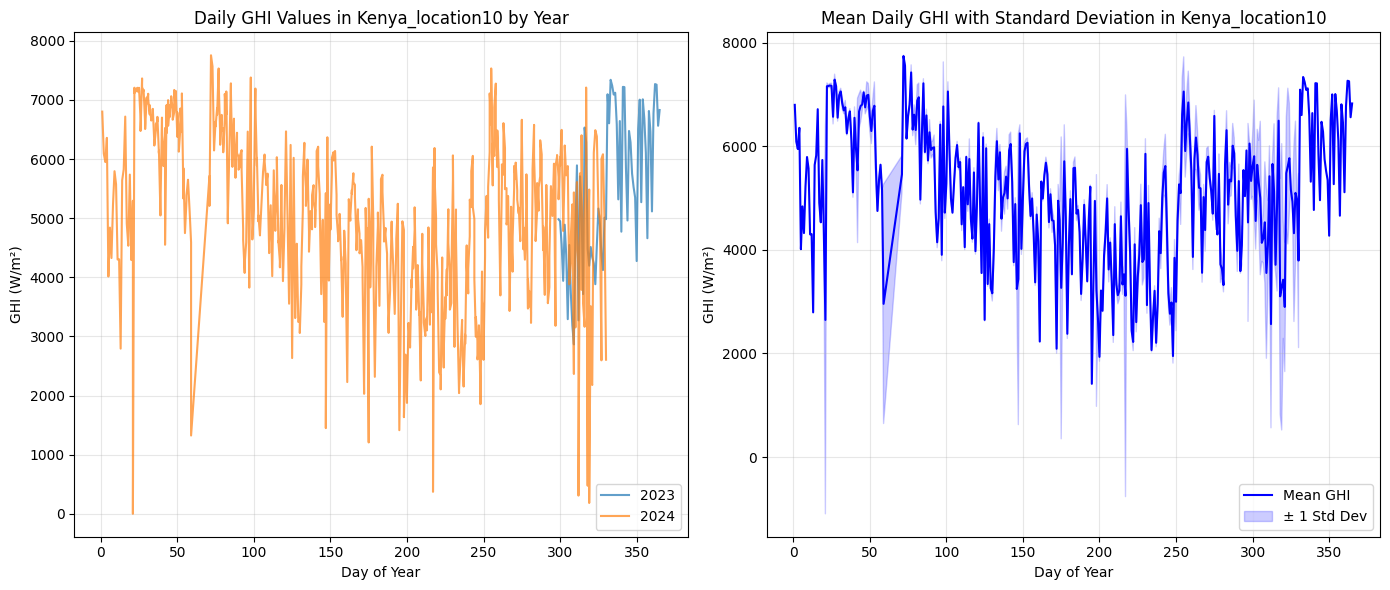

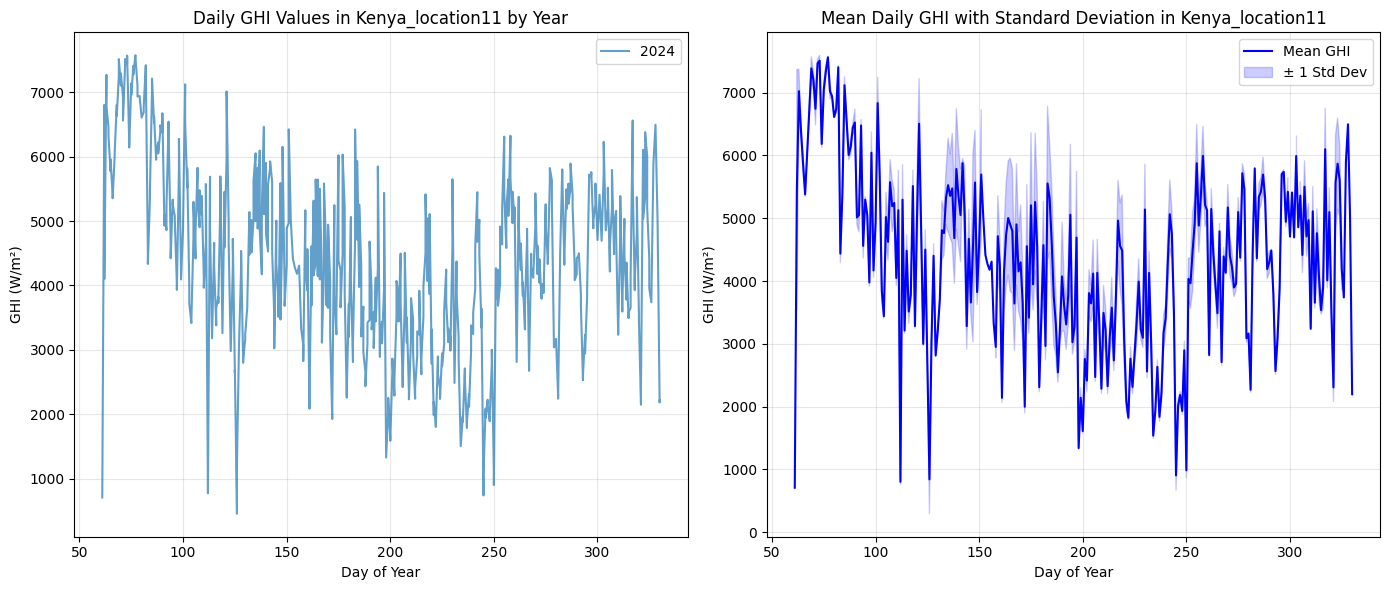

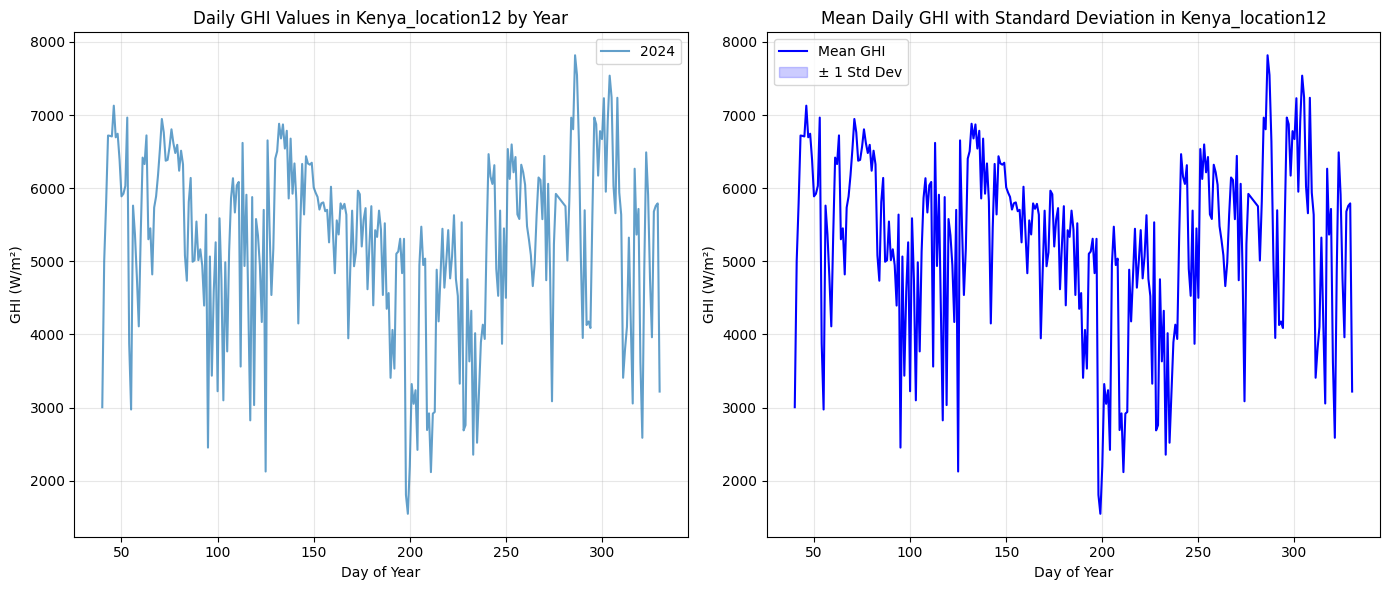

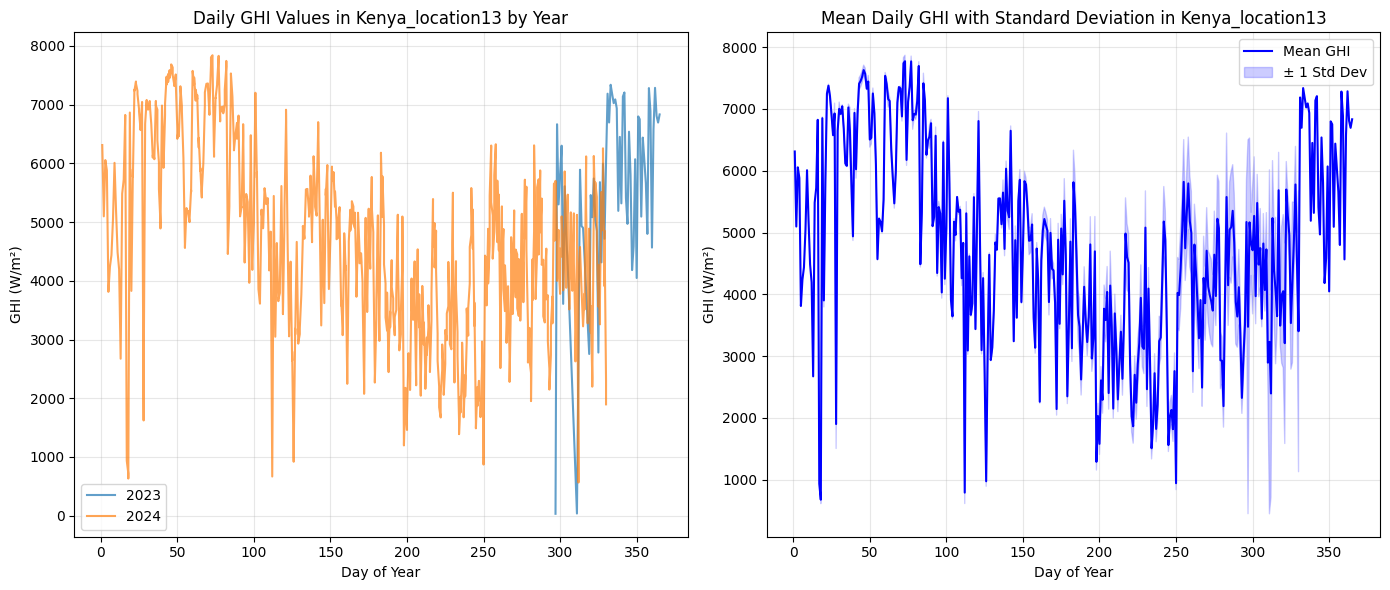

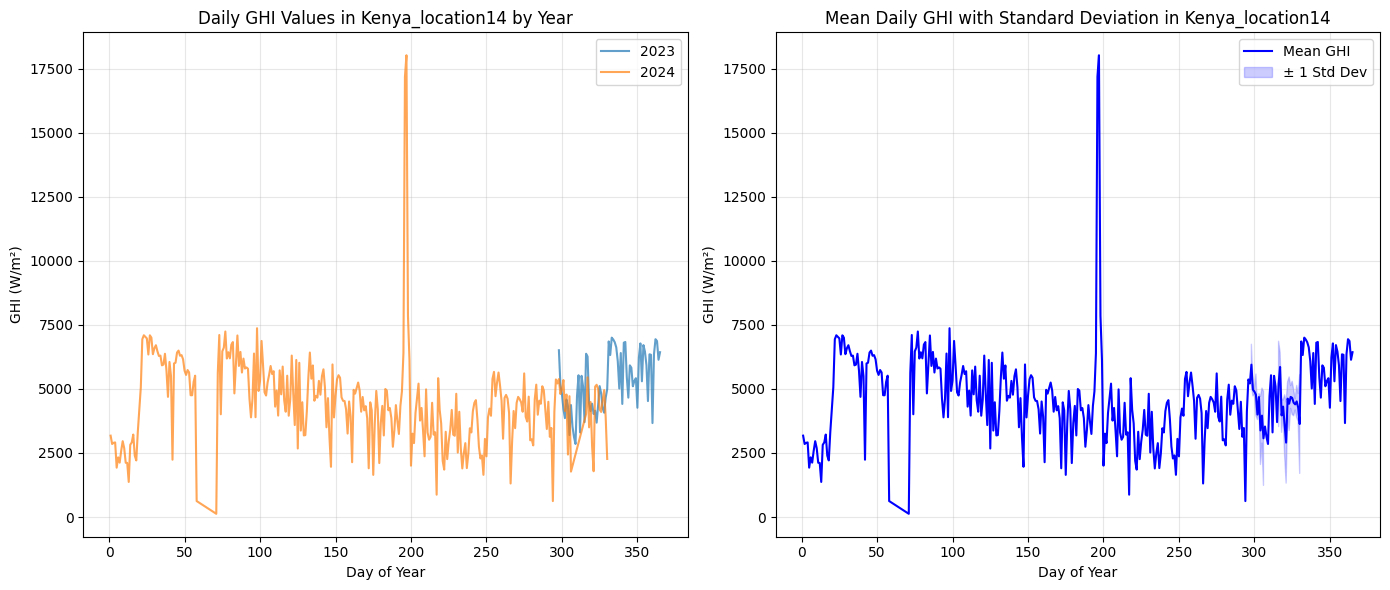

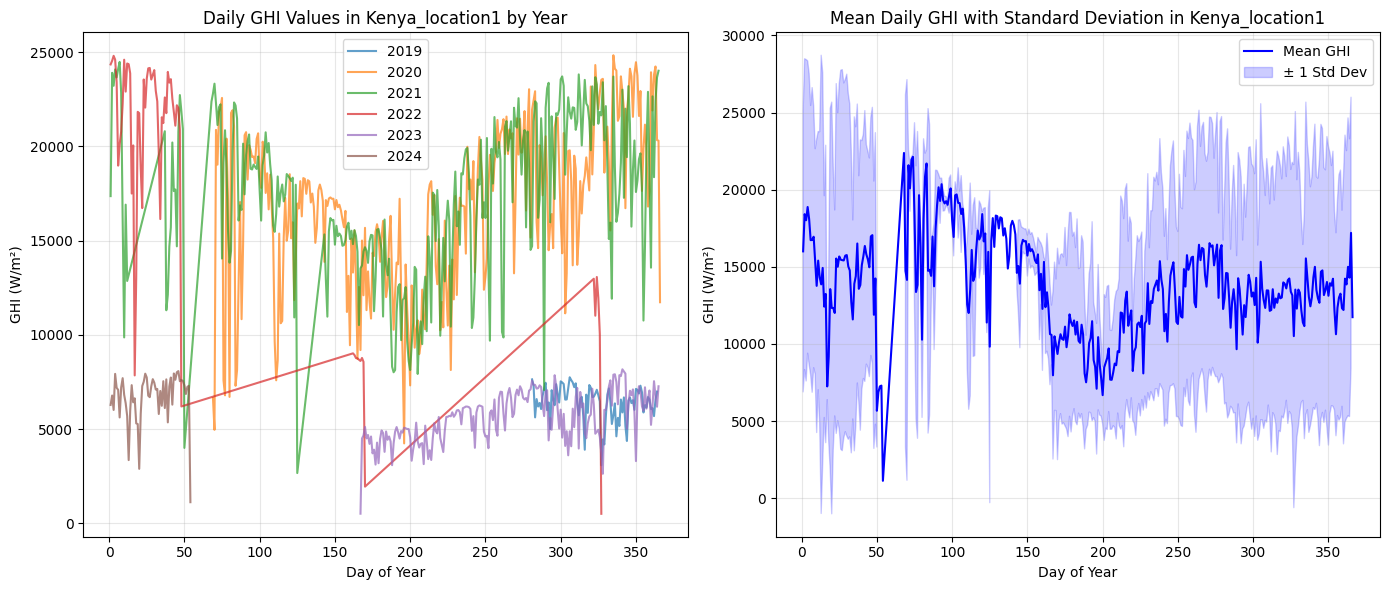

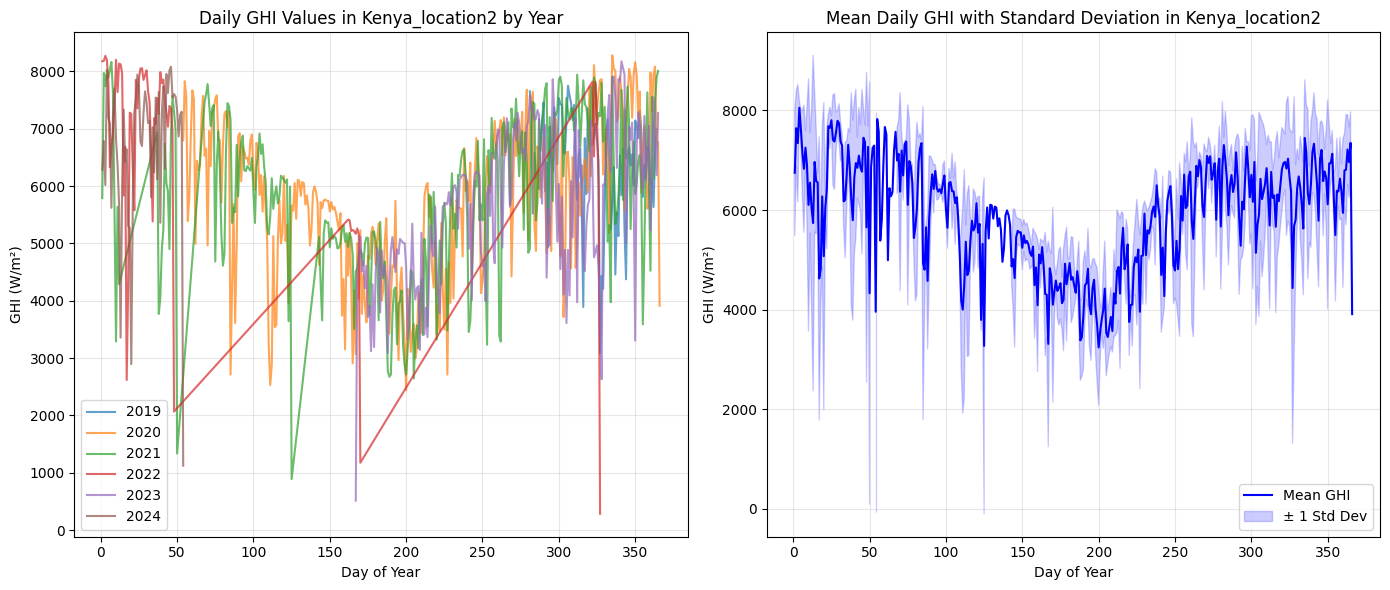

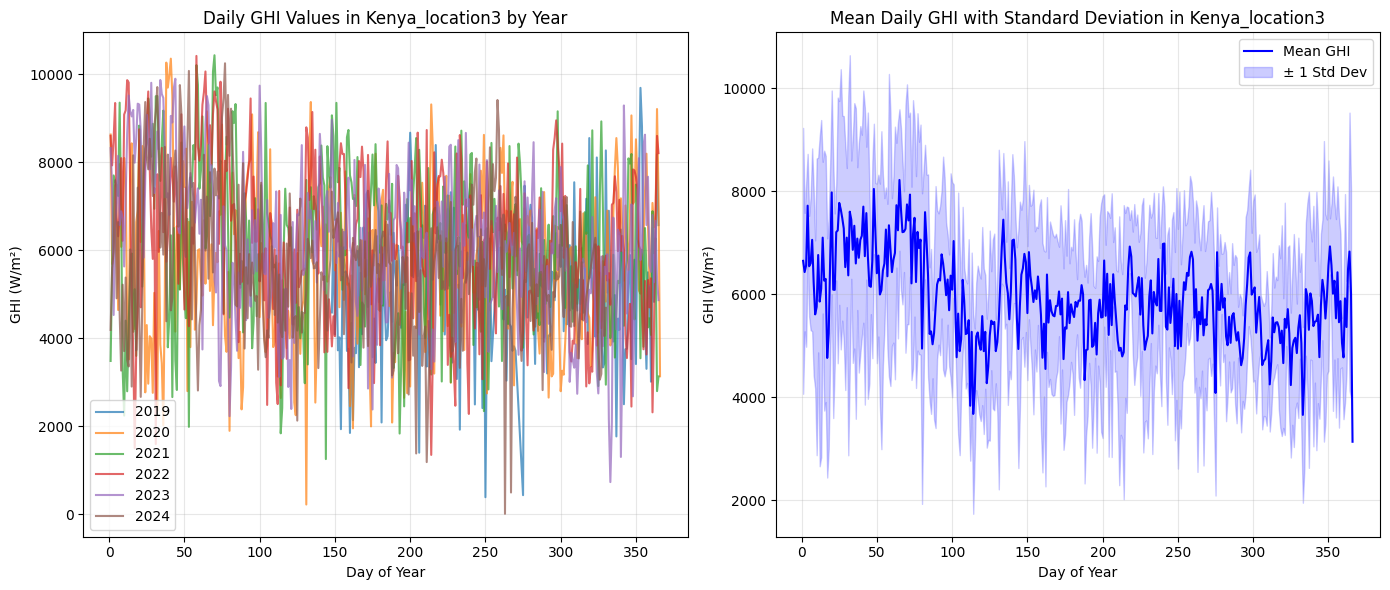

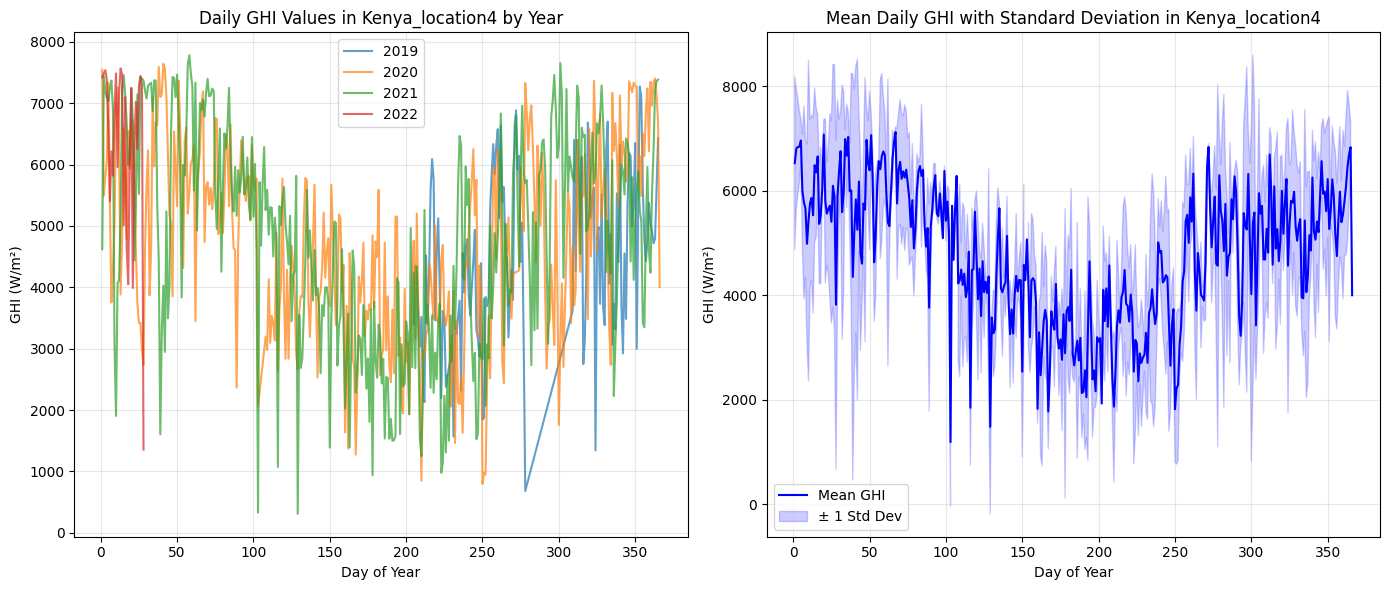

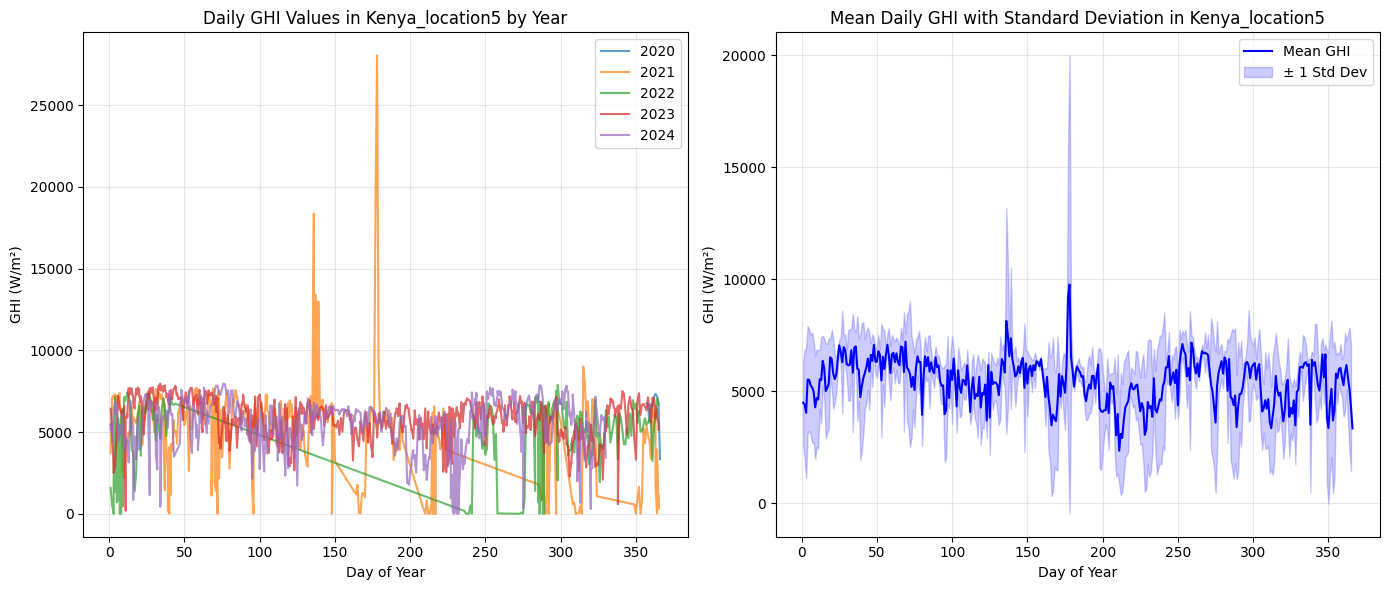

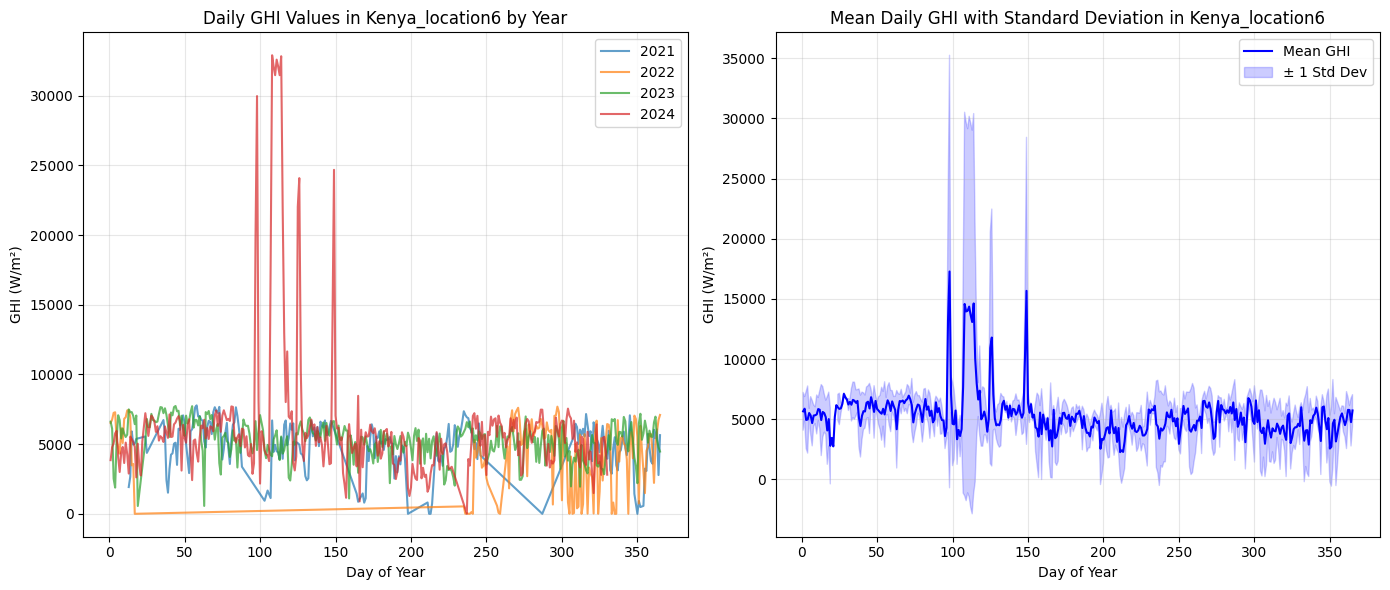

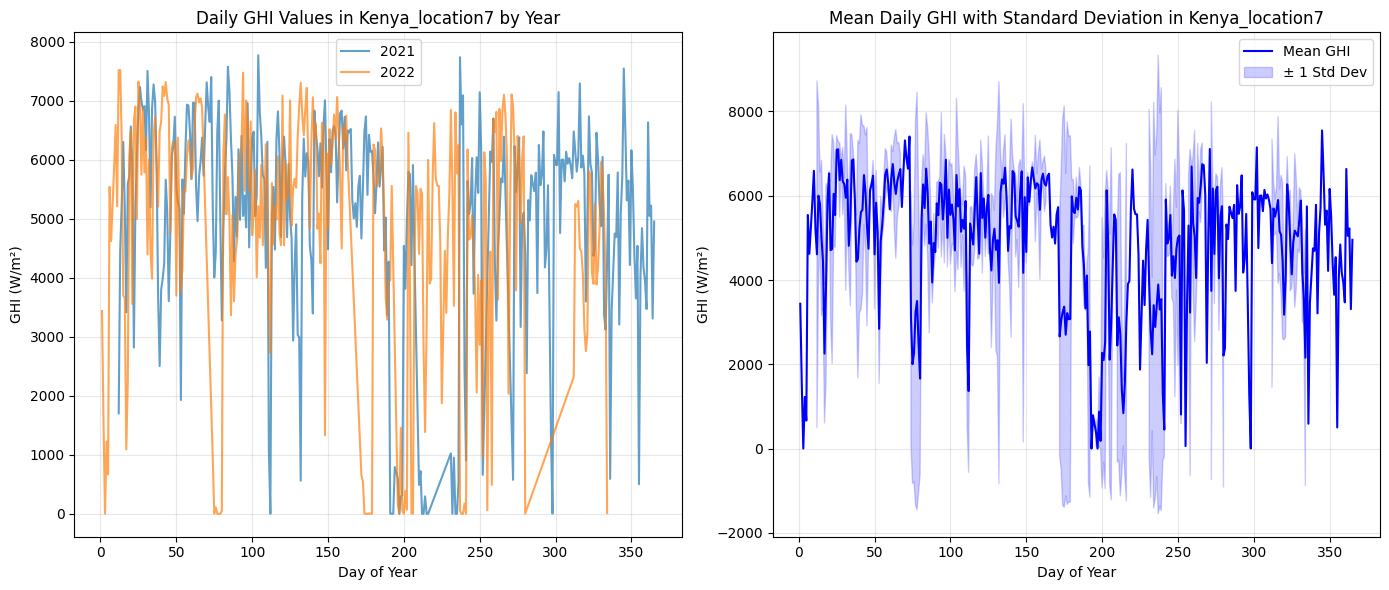

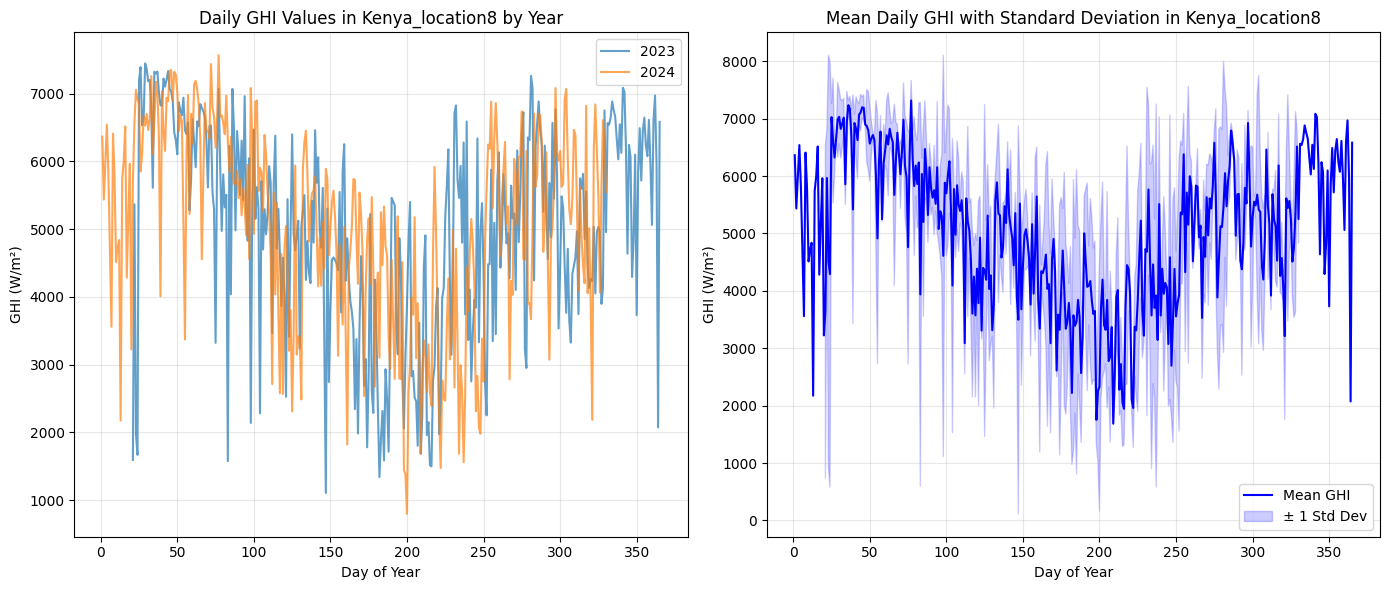

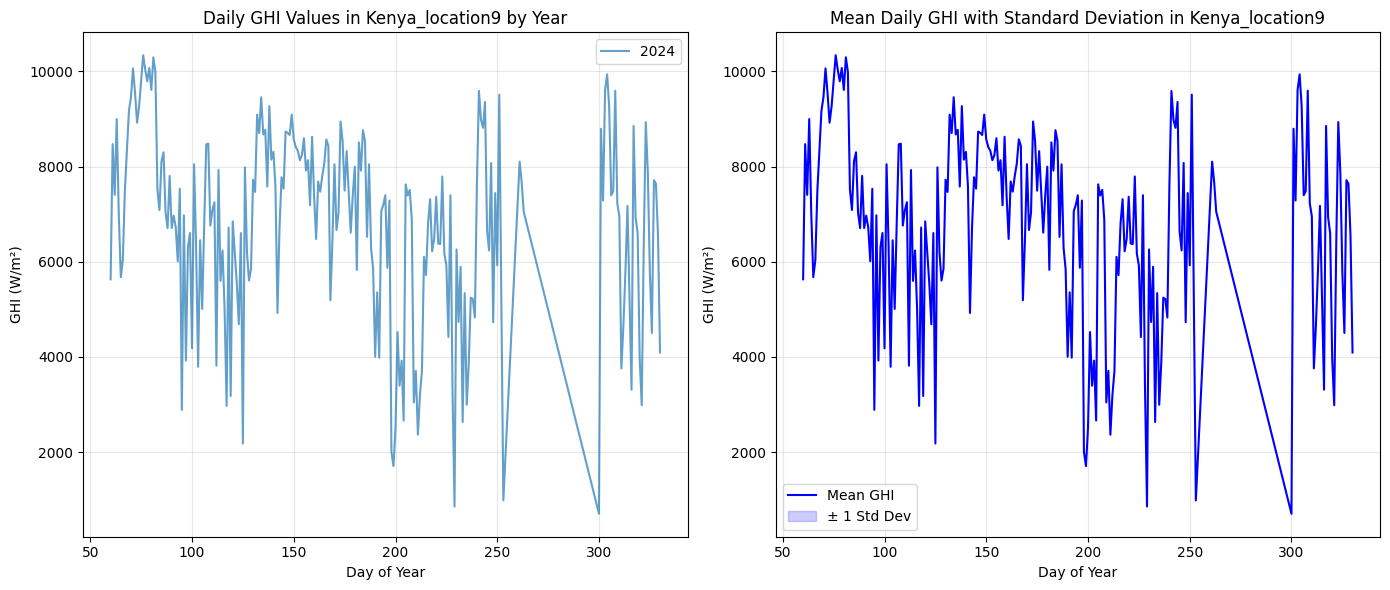

In [12]:
location = 'kenya'
kenya = pd.read_csv(cbe_measurements / f'{location}.csv')
fig, axes = plot_ghi_yearly_distribution(kenya)
plt.show()